# Karl Isaiah D. Buenafe

## 2022 - 2023 NSFG Exploratory Data Analysis

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import chi2_contingency as spchi
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

### Introduction

This analysis aims to apply the following statistical methods on the NSFG 2022–2023 dataset:
- Poisson regression
- Categorical data analysis 
- Exploratory data analysis with multiple comparisons 

## Raw Datasets

In [141]:
fdf = pd.read_csv("Female_Dataset.csv")
fdf

,CaseID,RSCRAGE,RSCRNINF,RSCRHISP,RSCRRACE,FTFMODE,DEVICE_TYPE,AGE_R,AGESCRN,HISP,...,CMLSTYR,CMJAN3YR,CMJAN4YR,CMJAN5YR,CMFIVYR,YEAR,QUARTER,PHASE1,PHASE2,PHASE3
0,96064,29,5,5,3,2,Mobile,29,29,5,...,1474,1441,1429,1417,1426,2,4,1,0,0
1,96066,18,5,1,4,2,PC,18,18,1,...,1471,1441,1429,1417,1423,2,2,1,1,1
2,96068,37,1,5,2,2,Mobile,37,37,5,...,1473,1441,1429,1417,1425,2,4,1,0,0
3,96071,40,1,5,3,2,PC,40,40,5,...,1468,1441,1429,1417,1420,2,2,1,0,0
4,96072,49,1,5,2,2,PC,49,49,5,...,1466,1441,1429,1417,1418,2,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5581,106009,20,1,5,1,2,PC,20,20,5,...,1462,1429,1417,1405,1414,1,4,1,0,0
5582,106010,46,5,5,3,1,Not applicable,46,46,5,...,1467,1441,1429,1417,1419,2,1,1,1,1
5583,106011,22,1,1,4,1,Not applicable,22,22,1,...,1458,1429,1417,1405,1410,1,2,1,1,0
5584,106013,20,5,5,1,2,PC,20,20,5,...,1470,1441,1429,1417,1422,2,3,1,0,0


Counting the number of columns in each dataset:

In [142]:
filename1 = "Female_Dataset.csv"
with open(filename1, "r", newline='') as file:
    reader = csv.DictReader(file)
    num_col1 = len(reader.fieldnames)
    


print(f"File '{filename1}' contains {num_col1} columns (from header).")


File 'Female_Dataset.csv' contains 1912 columns (from header).


To narrow down the number of columns for the analyses, we're going to have to filter the data by using the following variables:
- Count variable: e.g., number of sexual partners, number of pregnancies.

- Categorical (nominal): e.g., contraceptive method, smoking status.

- Ordered categorical: e.g., self-rated health status.

- Demographics: age, gender, education, race/ethnicity.

### Filtered dataset

In [151]:
columns = ['CaseID', 'AGE_R','RSCRRACE','HIEDUC','RELIGION','RELDLIFE', 
           'MARSTAT', 'vry1stag','LVSIT14F','LVSIT14M','MENARCHE','ECTIMESX',
           'CONDSEXL','PARTS1YR','CURRPRTT','DRINK12','MALSHT12','ABORTION',
           'WHOFSTPR','ONOWN','POT12','GRFSTSX','TOTINCR',"OPPLIFENUM"
]

nfdf = fdf.loc[:,columns]
nfdf

,CaseID,AGE_R,RSCRRACE,HIEDUC,RELIGION,RELDLIFE,MARSTAT,vry1stag,LVSIT14F,LVSIT14M,...,CURRPRTT,DRINK12,MALSHT12,ABORTION,WHOFSTPR,ONOWN,POT12,GRFSTSX,TOTINCR,OPPLIFENUM
0,96064,29,3,4,4,1.0,3,21.0,NaN,NaN,...,0,1.0,NaN,NaN,NaN,5,6.0,NaN,15,1.0
1,96066,18,4,5,2,2.0,3,NaN,NaN,NaN,...,0,1.0,NaN,NaN,NaN,5,1.0,NaN,11,NaN
2,96068,37,2,6,1,NaN,2,17.0,NaN,NaN,...,1,3.0,5.0,NaN,NaN,5,3.0,10.0,13,9.0
3,96071,40,3,10,1,NaN,1,16.0,NaN,NaN,...,1,3.0,5.0,0.0,NaN,5,1.0,11.0,15,8.0
4,96072,49,2,9,1,NaN,3,15.0,NaN,NaN,...,1,5.0,5.0,0.0,1.0,1,3.0,9.0,14,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5581,106009,20,1,4,1,NaN,3,20.0,NaN,NaN,...,1,4.0,5.0,NaN,NaN,5,1.0,NaN,2,1.0
5582,106010,46,3,6,4,1.0,1,23.0,1.0,3.0,...,1,1.0,5.0,0.0,7.0,5,1.0,NaN,4,1.0
5583,106011,22,4,7,1,NaN,1,14.0,NaN,NaN,...,1,1.0,9.0,NaN,NaN,1,1.0,8.0,8,15.0
5584,106013,20,1,5,4,3.0,3,NaN,1.0,1.0,...,0,4.0,NaN,NaN,NaN,1,2.0,NaN,15,1.0


Filtered data from female respondents

In [144]:
def print_desc(cols, df_desc):
    mask = df_desc['Variable Name'].isin(cols)
    for i, row in df_desc[mask].iterrows():
        print(f"{row['Variable Name']} : {row['Variable Label']}")

df_var_desc = pd.read_csv("var_code.csv")
print_desc(columns, df_var_desc)

MARSTAT : AD-7b R's marital or cohabiting status
ONOWN : AG-0a (before age 18) R ever live away from parents/guardians?
LVSIT14F : AG-3 female parent (figure) living with at age 14 - fam not intact thru 18
LVSIT14M : AG-4 male parent (figure) living with at age 14 - fam not intact thru 18
MENARCHE : BA-1 Age at first menstrual period (bottom-coded)
GRFSTSX : CE-8 Grade R Was in at First Sexual Intercourse (bottom-coded)
WHOFSTPR : CG-3 Who Was Rs First Sexual Partner
RELIGION : Current religious affiliation
ECTIMESX : EA-12 Number of times R used emergency contraception
HIEDUC : Highest completed year of school or highest degree received (bottom-coded)
RELDLIFE : IC-7 How important is religion in R's daily life
DRINK12 : JC-4 Last 12 mos: how often drank alcoholic beverages
POT12 : JC-6 Last 12 mos: how often smoked marijuana
CONDSEXL : JD-11 Was condom used at last sex of any kind with a male partner
MALSHT12 : JF-6 Last 12 mos: R had sex with male intravenous drug user
ABORTION : Num

In [145]:
nfdf.describe()

,CaseID,AGE_R,RSCRRACE,HIEDUC,RELIGION,RELDLIFE,MARSTAT,vry1stag,LVSIT14F,LVSIT14M,...,CURRPRTT,DRINK12,MALSHT12,ABORTION,WHOFSTPR,ONOWN,POT12,GRFSTSX,TOTINCR,OPPLIFENUM
count,5586.000000,5586.000000,5586.000000,5586.000000,5586.000000,3637.000000,5586.000000,4554.000000,1733.000000,1733.000000,...,5586.000000,5564.000000,4057.000000,3034.000000,1454.000000,5586.000000,5561.000000,2513.000000,5586.000000,4652.000000
mean,101053.653777,32.362871,2.835840,5.863409,2.222521,1.761342,2.136591,17.927097,1.290825,2.431044,...,0.670605,2.989396,5.040424,0.243902,9.094223,4.467777,1.843913,15.591325,11.201933,72.732803
std,2863.167055,9.532618,0.868267,2.684175,1.033755,1.081249,0.959407,4.170320,0.639096,1.162593,...,0.504219,1.726197,0.575933,0.646457,9.556947,1.375232,1.671412,21.287587,4.246779,246.206924
min,96064.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000
25%,98586.250000,25.000000,2.000000,4.000000,1.000000,1.000000,1.000000,15.000000,1.000000,1.000000,...,0.000000,1.000000,5.000000,0.000000,7.000000,5.000000,1.000000,9.000000,9.000000,2.000000
50%,101032.500000,33.000000,3.000000,6.000000,2.000000,2.000000,3.000000,17.000000,1.000000,3.000000,...,1.000000,3.000000,5.000000,0.000000,7.000000,5.000000,1.000000,10.000000,13.000000,5.000000
75%,103557.500000,40.000000,3.000000,8.000000,3.000000,2.000000,3.000000,19.000000,1.000000,3.000000,...,1.000000,5.000000,5.000000,0.000000,9.000000,5.000000,2.000000,11.000000,15.000000,10.000000
max,106019.000000,50.000000,4.000000,11.000000,4.000000,9.000000,9.000000,97.000000,9.000000,9.000000,...,3.000000,9.000000,9.000000,6.000000,99.000000,9.000000,9.000000,99.000000,15.000000,999.000000


Summary of the cleaned female responses

### Descriptive Analysis

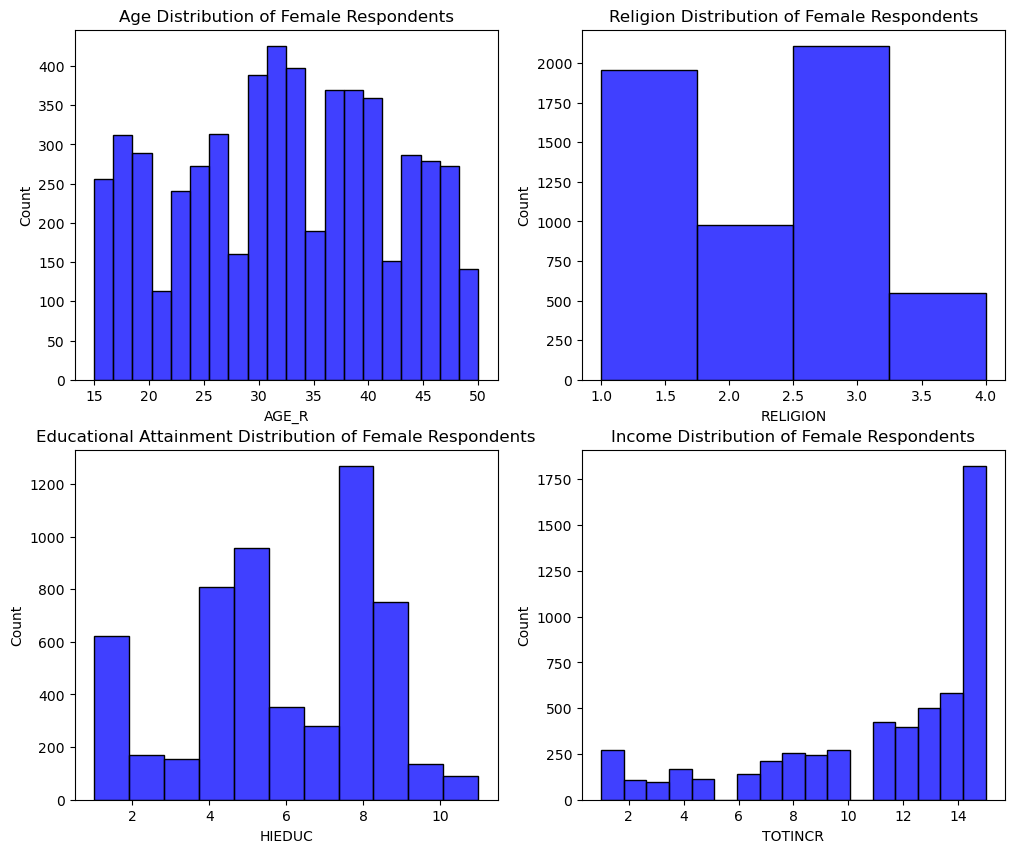

In [170]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(ax = axes[0,0], data = nfdf['AGE_R'], bins = 20, linewidth=1, color="blue")
axes[0,0].set_title("Age Distribution of Female Respondents")

sns.histplot(ax = axes[0,1], data = nfdf['RELIGION'], bins = 4, linewidth=1, color="blue")
axes[0,1].set_title("Religion Distribution of Female Respondents")

sns.histplot(ax = axes[1,0], data = nfdf['HIEDUC'], bins = 11, linewidth=1, color="blue")
axes[1,0].set_title("Educational Attainment Distribution of Female Respondents")

sns.histplot(ax = axes[1,1], data = nfdf['TOTINCR'], bins = 17, linewidth=1, color="blue")
axes[1,1].set_title("Income Distribution of Female Respondents")

plt.show()

In [147]:
null_count = nfdf['DRINK12'].isnull().sum()
print(f"Number of null values in TOTINCR: {null_count}")

Number of null values in TOTINCR: 22


In [148]:

female_age = sp.shapiro(nfdf['AGE_R'])

print(f"Female respondents age normality test:\n{female_age}")

Female respondents age normality test:
ShapiroResult(statistic=0.9662719964981079, pvalue=2.984284216851419e-34)


/Users/periperipapi/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Remarks: From the figures and the test above we can see that the age female respondents are normally ditributed. In terms of the religion of the respondents, majority of them are either protestants or are not affiliated with any religions. When it comes to distribution of educational attainment and total income, the graph of both show that they're similar.

### STATISTICAL ANALYSES

### Poisson Regression

#### Female Respondents Model:
Sexual partner count based on the highest educational attainment and the self-rated importance of religion of Female Respondents

In [149]:
model_null= smf.poisson(formula = 'PARTS1YR ~ 1', data=nfdf).fit()

print(model_null.summary())

print(f"Expected average number of sexual partner per year:{np.exp(model_null.params['Intercept'])}")

Optimization terminated successfully.
         Current function value: 1.220495
         Iterations 1
                          Poisson Regression Results                          
Dep. Variable:               PARTS1YR   No. Observations:                 4554
Model:                        Poisson   Df Residuals:                     4553
Method:                           MLE   Df Model:                            0
Date:                Sun, 18 May 2025   Pseudo R-squ.:                   0.000
Time:                        15:11:16   Log-Likelihood:                -5558.1
converged:                       True   LL-Null:                       -5558.1
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0369      0.015      2.534      0.011       0.008       0.065
Expected average number of se

Remark: From the null model, it suggests that the predicted average number of sexual partner per year is 2 at most

#### Poisson Regression with predictors
for this analysis, we must first remove all the rows that contain null values. 

In [152]:
cfdf = nfdf.dropna(subset=['PARTS1YR',  'HIEDUC', 'RELDLIFE'])
cfdf.describe()

,CaseID,AGE_R,RSCRRACE,HIEDUC,RELIGION,RELDLIFE,MARSTAT,vry1stag,LVSIT14F,LVSIT14M,...,CURRPRTT,DRINK12,MALSHT12,ABORTION,WHOFSTPR,ONOWN,POT12,GRFSTSX,TOTINCR,OPPLIFENUM
count,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,906.000000,906.000000,...,2970.000000,2960.000000,2609.000000,2099.000000,1063.000000,2970.000000,2958.000000,1517.000000,2970.000000,2942.000000
mean,101103.410101,35.050842,2.845791,6.145455,2.876431,1.746465,1.943434,18.233333,1.289183,2.474614,...,0.826936,3.046622,5.054810,0.208194,8.685795,4.375421,1.741379,14.542518,11.169360,75.692046
std,2853.828423,8.383638,0.868089,2.498175,0.631936,1.031026,0.978464,4.512447,0.560420,1.082210,...,0.424512,1.688036,0.590428,0.628986,8.738030,1.459502,1.611083,19.422746,4.204194,252.654014
min,96064.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000
25%,98628.750000,29.000000,2.000000,4.000000,2.000000,1.000000,1.000000,15.000000,1.000000,2.000000,...,1.000000,2.000000,5.000000,0.000000,7.000000,5.000000,1.000000,9.000000,9.000000,2.000000
50%,101146.500000,35.000000,3.000000,6.000000,3.000000,2.000000,2.000000,17.000000,1.000000,3.000000,...,1.000000,3.000000,5.000000,0.000000,7.000000,5.000000,1.000000,10.000000,13.000000,4.000000
75%,103600.750000,42.000000,3.000000,8.000000,3.000000,2.000000,3.000000,20.000000,2.000000,3.000000,...,1.000000,5.000000,5.000000,0.000000,8.000000,5.000000,1.000000,11.000000,15.000000,10.000000
max,106010.000000,50.000000,4.000000,11.000000,4.000000,9.000000,9.000000,97.000000,8.000000,9.000000,...,3.000000,9.000000,9.000000,6.000000,99.000000,8.000000,9.000000,99.000000,15.000000,999.000000


Summary of the cleaned dataset

In [153]:
model= smf.poisson(formula = 'PARTS1YR ~ HIEDUC + RELDLIFE', data=cfdf).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 1.194489
         Iterations 4
                          Poisson Regression Results                          
Dep. Variable:               PARTS1YR   No. Observations:                 2970
Model:                        Poisson   Df Residuals:                     2967
Method:                           MLE   Df Model:                            2
Date:                Sun, 18 May 2025   Pseudo R-squ.:                0.001074
Time:                        15:17:21   Log-Likelihood:                -3547.6
converged:                       True   LL-Null:                       -3551.4
Covariance Type:            nonrobust   LLR p-value:                   0.02205
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0543      0.055      0.982      0.326      -0.054       0.163
HIEDUC        -0.0156      0.

Remark: The Poisson Regression conducted on the number of sexual partners in a year based on the highest educational attainment and the rated importance of religion in the lives of the female produced produced an opposing effect. Based on the model, a higher educational attainment negatively affects the number of partner, while the higher rate of importance of religion produces a positive effect on the number of partner. However, given these interpretation, the values of the model are still siginificantly small, and that the Pseudo R-squared value is also significantly small at 0.001. This means that the model cannot explain the variance of majority of the model, making it a bad fit.

### Contingency Tables

In [165]:
rced = pd.crosstab(index=nfdf['RSCRRACE'], columns=nfdf['HIEDUC'])
rced

HIEDUC,1,2,3,4,5,6,7,8,9,10,11
RSCRRACE,,,,,,,,,,,
1,32,6,9,61,62,17,21,163,146,25,22
2,107,43,35,206,198,83,52,140,67,11,5
3,255,49,78,315,490,175,164,785,466,83,57
4,229,71,31,225,206,78,45,179,73,16,5


Race (1 = other race, 2 = Black, 3 = White, 4 = Hispanic) x Highest educational attainment

In [220]:
stat, p1, dof, exp = spchi(rced)

alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 stands)')

p value is 2.3945464211704216e-09
Dependent (reject H0)


Remark: After conducting Chi-squared test on the conitingency table of race and educational attaiment of female respondents, it shows that they're dependent of each other, suggesting the race affects the highest educational attainment of the female respondents.

In [172]:
inced = pd.crosstab(index=cfdf['TOTINCR'], columns=cfdf['HIEDUC'])
inced

HIEDUC,1,2,3,4,5,6,7,8,9,10,11
TOTINCR,,,,,,,,,,,
1,22,9,9,35,28,15,5,10,1,1,0
2,5,5,2,14,14,4,5,5,0,0,0
3,9,5,4,4,15,3,2,3,1,1,0
4,16,6,9,18,19,9,5,10,3,0,0
5,6,3,2,15,16,6,3,7,0,0,0
6,15,1,5,16,25,7,3,3,2,0,0
7,22,4,4,31,30,11,5,10,5,1,0
8,19,10,8,28,25,17,11,16,5,1,0
9,11,6,6,20,37,16,5,23,9,0,0


Contingency table of total income and highest educational attainment

In [221]:
stat, p2, dof, exp = spchi(inced)

alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 stands)')

p value is 2.3945464211704216e-09
Dependent (reject H0)


Remark: After conducting Chi-squared test on the conitingency table of income and educational attaiment of female respondents, it shows that they're dependent of each other, suggesting the the total income affects the highest educational attainment of the female respondents.

In [174]:
rcinc = pd.crosstab(index=nfdf['RSCRRACE'], columns=nfdf['TOTINCR'])
rcinc

TOTINCR,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
RSCRRACE,,,,,,,,,,,,,,,
1,10,10,4,4,10,6,12,18,18,11,30,44,57,58,272
2,91,38,35,53,37,35,54,63,59,67,85,68,77,72,113
3,97,31,28,70,37,57,79,95,94,119,195,179,272,355,1209
4,72,27,28,39,28,40,65,79,72,73,112,105,93,98,227


Contingency table of race and total income

In [222]:
stat, p3, dof, exp = spchi(rcinc)

alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 stands)')

p value is 2.3945464211704216e-09
Dependent (reject H0)


Remark: After conducting Chi-squared test on the conitingency table of race and total income of female respondents, it shows that they're dependent of each other, suggesting the the race affects total income of the female respondents.

In [191]:
cfdf = nfdf.dropna(subset = ["RELIGION", "ABORTION"])
rlab = pd.crosstab(index=nfdf['RELIGION'], columns=nfdf['ABORTION'])
rlab

ABORTION,0.0,1.0,2.0,3.0,4.0,5.0,6.0
RELIGION,,,,,,,
1,690,151,51,11,3,1,0
2,499,34,16,4,0,1,0
3,1102,130,34,12,2,3,3
4,235,38,5,7,1,0,1


COntingency table of religion and number of abortion

In [223]:
stat, p4, dof, exp = spchi(rlab)

alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 stands)')

p value is 2.3945464211704216e-09
Dependent (reject H0)


Remark: Based on the Chi-squared test on the contingency table of religion and number of abortion, it shows that religion also affects the number of abortion one had.

### VISUALIZING THE TABLES

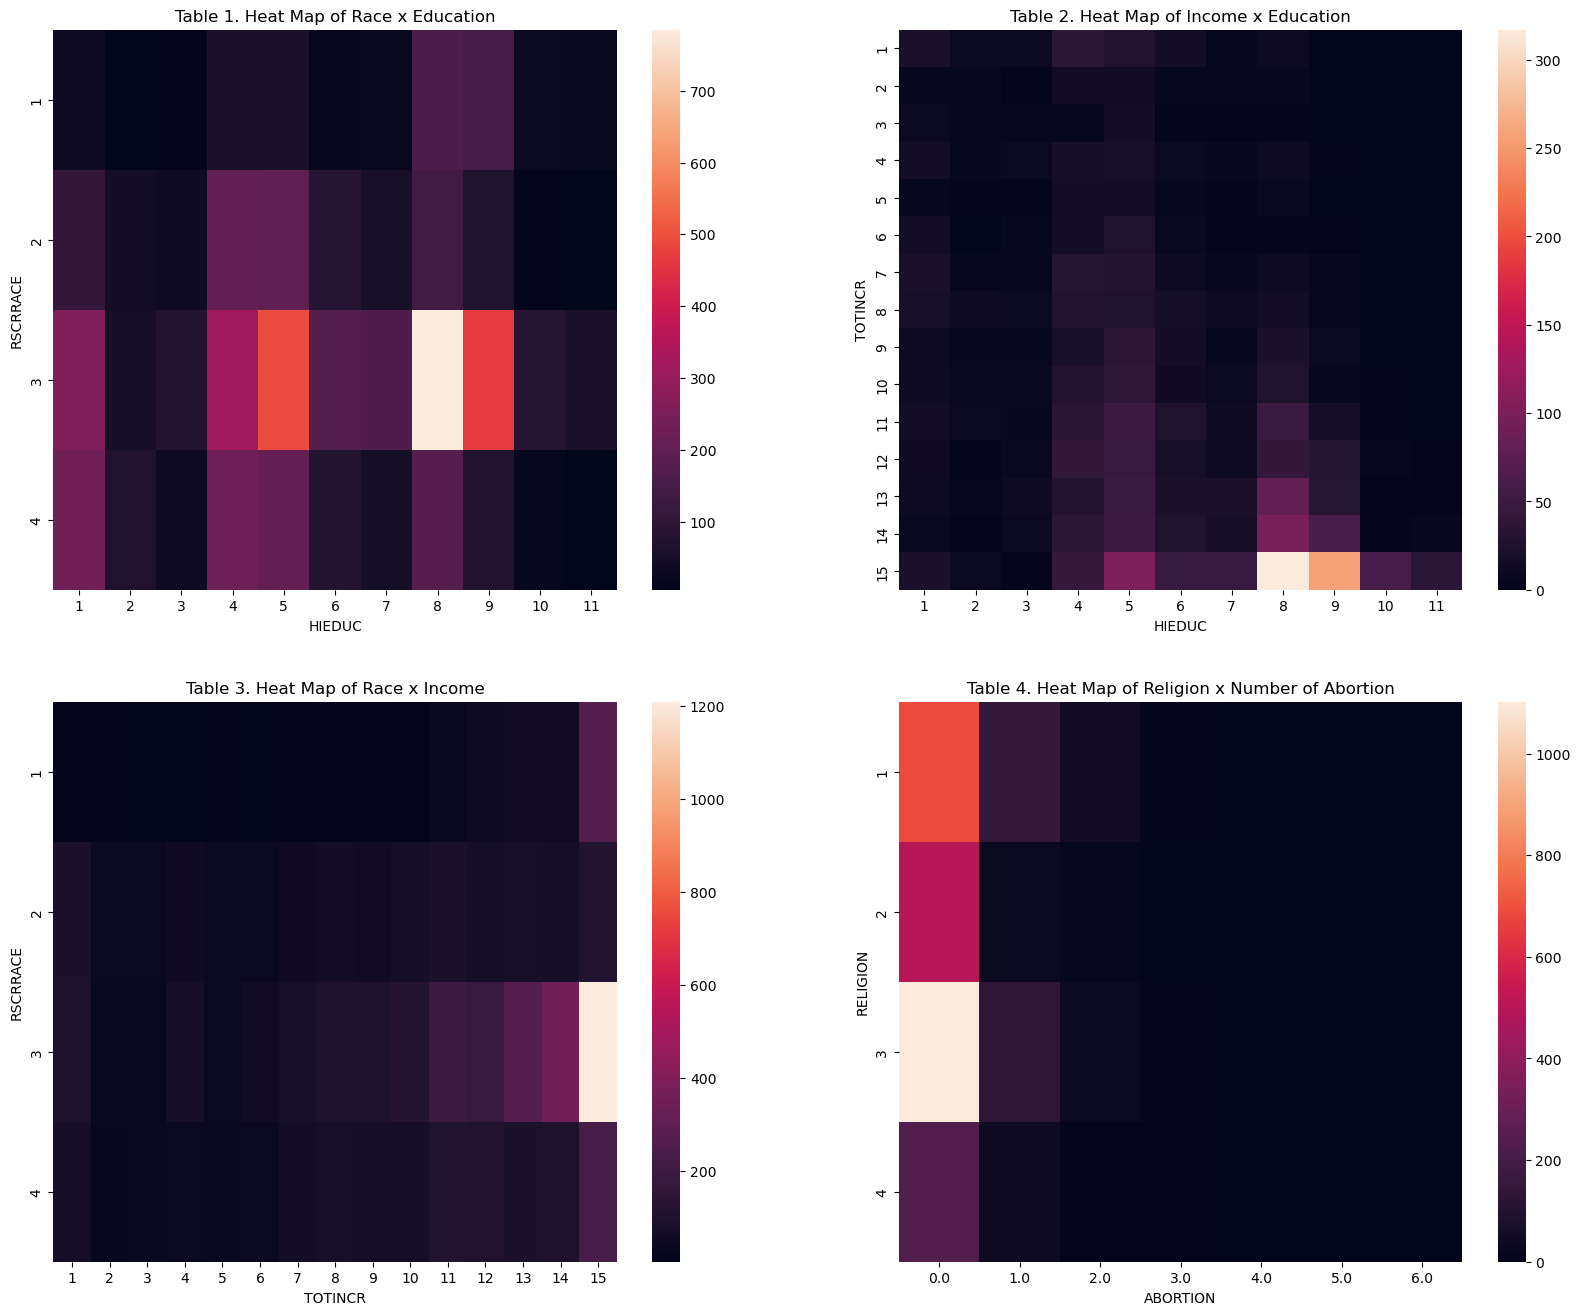

In [194]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.heatmap(ax = axes[0,0], data = rced)
axes[0,0].set_title("Table 1. Heat Map of Race x Education")

sns.heatmap(ax = axes[0,1], data = inced)
axes[0,1].set_title("Table 2. Heat Map of Income x Education")

sns.heatmap(ax = axes[1,0], data = rcinc)
axes[1,0].set_title("Table 3. Heat Map of Race x Income")

sns.heatmap(ax = axes[1,1], data = rlab)
axes[1,1].set_title("Table 4. Heat Map of Religion x Number of Abortion")


plt.show()

Remarks:

- Table 1: The heat map of race x education shows a significantly higher number of observations on the higher level of education for white female respondents

- Table 2:The heat map of income x education shows a significantly higher number of observations on the higher level of education for female respondents with higher income

- Table 3:The heat map of income x education shows a significantly higher number of observations on the higher level of education for female respondents with higher income

- Table 4:The heat map of religion x number of abortion shows a significantly higher number of observations of not have had abotion for protestant female respondents.

### False Discovery Rate (FDR) methods.

Extending the contingency tables for other variables:

In [232]:
cfdf= nfdf.dropna(subset=["RELIGION", "OPPLIFENUM", "HIEDUC"])
_,p5 = ttest_ind(cfdf["RELIGION"], cfdf["OPPLIFENUM"])
_,p6 = ttest_ind(cfdf["HIEDUC"], cfdf["OPPLIFENUM"])
p_vals=[p1,p2,p3,p4,p5,p6]

p_vals

[3.683084760950963e-110,
 6.730760952340249e-118,
 2.793114246517547e-119,
 2.3945464211704216e-09,
 2.681586325664315e-83,
 1.678715860497786e-74]

In [229]:
rejected, pvals_corrected, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')


for i, (p, corr_p, reject) in enumerate(zip(p_vals, pvals_corrected, rejected)):
    print(f"Test {i+1}: raw p = {p:.3f}, corrected p = {corr_p:.3f}, reject: {reject}")

Test 1: raw p = 0.000, corrected p = 0.000, reject: True
Test 2: raw p = 0.000, corrected p = 0.000, reject: True
Test 3: raw p = 0.000, corrected p = 0.000, reject: True
Test 4: raw p = 0.000, corrected p = 0.000, reject: True
Test 5: raw p = 0.000, corrected p = 0.000, reject: True
Test 6: raw p = 0.000, corrected p = 0.000, reject: True


Remark: The corrected p-values after conducting the FDR Method did not change the result of the initial findings.

## SUMMARY

Conducting multiple statistical analyses on the gathered data from female respondent had led to numerous findings. 

- Regardless of any factor, their expected number of sexual partner in a year will be 2 at max.

- The number of sexual partner cannot be determined based on their Religion, educational attainment, or total income.

- After conducting Chi-squared test on various contingency tables, the returned scores suggested the following:

     (1) There's a relationship between race and the highest attained education of the female respondents
     (2) There's a relationship between race and the total income of the female respondents
     (3) There's a relationship between total income and the highest attained education of the female respondents
     (4) There's a relationship between religion and the number of abortion a female respondent has had.
     
     
Lastly, using independent tests and applying the flase discovery rate method to determine if there's a relationship between the religion and the number of sexual partner  a female respondent has had in their lifetime,  if there's a relationship between the highest attained education and the number of sexual partner  a female respondent has had in their lifetime, the returned statistical scores suggest that there is.